# 01 · Calidad y limpieza del dataset

**Propósito.** Pasar del dataset que sale del pipeline (`data/processed/propiedades_enriquecidas.tsv`)
a una versión limpia y trazable para el análisis exploratorio (`data/processed/propiedades_limpias.tsv`).

**Cadena de trabajo de cada sección:** pregunta → datos → transformación → control → resultado → interpretación.

**Criterio general.** No se elimina nada automáticamente. Se excluye solo lo que está fuera del alcance
(departamentos usados en venta, en USD) o es imposible de interpretar. Todo lo demás se corrige con una
regla documentada o se **marca** con una columna para que el análisis decida.

La lógica reutilizable está en `src/limpieza.py`. Este notebook la usa y muestra los controles.

## 1. Configuración e ingesta

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Raíz del repo: el notebook vive en /notebooks
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src import limpieza
from src.indice_confort import tipo_de_columna

**Parámetros centralizados.** Todo umbral o dato externo que afecta el resultado está acá, no
desparramado en el código.

In [3]:
PARAMS = {
    "entrada": RAIZ / "data" / "processed" / "propiedades_enriquecidas.tsv",
    "salida": RAIZ / "data" / "processed" / "propiedades_limpias.tsv",
    "salida_registro": RAIZ / "data" / "processed" / "registro_limpieza.csv",
    "fecha_extraccion": "2026-08-14",   # fecha del scraping (cuotas 1 a 5)
    "anio_referencia": 2026,            # para convertir "año de construcción" en edad
    "precio_minimo_usd": 20_000,        # por debajo: alquiler o error de carga
    "precio_m2_maximo_usd": 50_000,     # por encima: error de carga (el máximo real ronda 20.000)
    "m2_minimo": 15,
    "m2_maximo": 1000,
    "antiguedad_maxima": 150,
    "expensas_maximo_ars": 10_000_000,
    "iqr_k": 1.5,
    "tipo_cambio_ars_usd": 1518.05,     # dólar MEP, cierre del 14/08/2026 (Ámbito). Ver sección 3.4
}

In [4]:
df_crudo = pd.read_csv(PARAMS["entrada"], sep="\t", low_memory=False)
print(f"Filas: {df_crudo.shape[0]:,} | Columnas: {df_crudo.shape[1]}")
print(f"Fecha de extracción: {PARAMS['fecha_extraccion']}")

Filas: 27,922 | Columnas: 93
Fecha de extracción: 2026-08-14


**Unidad de análisis:** el aviso de un departamento usado en venta en CABA, publicado en MercadoLibre.
Se compara dentro de su zona de referencia: la sub-zona (cluster espacial dentro del barrio) o el barrio completo, según dónde dé una referencia más precisa (notebook 03).

`df_crudo` no se modifica en todo el notebook: todas las transformaciones van sobre `df`, una copia.

In [5]:
df = df_crudo.copy()
df.dtypes.value_counts()

object     77
float64    12
int64       3
bool        1
Name: count, dtype: int64

## 2. Evaluación de calidad

### 2.1 Identificador y duplicados

**Pregunta:** ¿cada fila es un aviso distinto?

In [6]:
df["id_aviso"] = limpieza.extraer_id_aviso(df["link"])

print("Duplicados por link completo:", df["link"].duplicated().sum())
print("Duplicados por ID de aviso:  ", df["id_aviso"].duplicated().sum())
print("Avisos sin ID:               ", df["id_aviso"].isna().sum())

Duplicados por link completo: 0
Duplicados por ID de aviso:   68
Avisos sin ID:                0


In [7]:
dup_id = df[df["id_aviso"].duplicated(keep=False)]
barrios_por_id = dup_id.groupby("id_aviso")["barrio"].nunique()
print("IDs repetidos:", dup_id["id_aviso"].nunique())
print("  en dos barrios distintos:", (barrios_por_id > 1).sum())
print("  con precio distinto:", (dup_id.groupby("id_aviso")["precio"].nunique() > 1).sum())
dup_id.sort_values("id_aviso")[["id_aviso", "barrio", "precio", "m2", "subzona"]].head(6)

IDs repetidos: 68
  en dos barrios distintos: 27
  con precio distinto: 0


,id_aviso,barrio,precio,m2,subzona
24126,MLA1661865565,floresta,269700,78.0,floresta_4
26188,MLA1661865565,villa-santa-rita,269700,78.0,villa-santa-rita_0
24123,MLA1662991427,floresta,145000,42.0,floresta_4
26185,MLA1662991427,villa-santa-rita,145000,42.0,villa-santa-rita_0
24125,MLA1663185651,floresta,280000,63.0,floresta_4
26187,MLA1663185651,villa-santa-rita,280000,63.0,villa-santa-rita_0


**Resultado.** El link incluye parámetros de seguimiento que cambian en cada búsqueda, por eso la
deduplicación del pipeline (por link) no detectó estos casos. El ID del aviso (`MLA...`) sí es estable.
En 27 de los 68 casos es el mismo aviso devuelto por la búsqueda de dos barrios vecinos; el resto aparece dos veces en la misma búsqueda.

> **Interpretación.** La columna `barrio` no la declara el anunciante: es el barrio de la búsqueda con la que el scraper encontró el aviso. Como MercadoLibre incluye avisos de barrios vecinos en cada búsqueda, el mismo aviso puede aparecer en dos barrios, y en general `barrio` es poco confiable cerca de los límites.
>
> Para los 68 duplicados se conservó la primera aparición, una regla operativa sin fundamento geográfico. La corrección de fondo es asignar el barrio a partir de `lat`/`lon` con los polígonos oficiales de BA Data, cosa que solo es posible para el 82% geocodificado. Queda como próximo paso, y mientras tanto el análisis se apoya en la sub-zona, que ya se construyó con coordenadas y no depende de `barrio`.

### 2.2 Tipos de datos y cardinalidad

**Pregunta:** ¿cada columna tiene el tipo que corresponde a lo que mide?

In [8]:
resumen = pd.DataFrame({
    "tipo": df_crudo.dtypes.astype(str),
    "valores_unicos": df_crudo.nunique(),
    "pct_nulos": (100 * df_crudo.isna().mean()).round(1),
    "ejemplo": df_crudo.apply(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan),
})
with pd.option_context("display.max_rows", 120):
    display(resumen.sort_values("valores_unicos"))

,tipo,valores_unicos,pct_nulos,ejemplo
tipo,object,1,0.0,Departamento en venta
es_emprendimiento,bool,1,0.0,False
desayunador,object,1,95.4,Sí
placards,object,1,75.3,Sí
recepcion,object,1,97.9,Sí
toilette,object,1,72.3,Sí
amoblado,object,1,95.4,Sí
parrilla,object,1,85.0,Sí
dependencia_de_servicio,object,1,92.4,Sí
salon_de_usos_multiples,object,1,88.7,Sí


In [9]:
# Columnas numéricas guardadas como texto (tienen unidad pegada al número)
texto_con_unidad = ["precio_texto", "superficie_total", "superficie_cubierta", "antig_edad",
                    "expensas", "superficie_de_balcon"]
resumen.loc[texto_con_unidad, ["tipo", "ejemplo"]]

,tipo,ejemplo
precio_texto,object,US$278.000
superficie_total,object,"103,71 m²"
superficie_cubierta,object,"103,71 m²"
antig_edad,object,71 años
expensas,object,290.000 ARS
superficie_de_balcon,object,25 m²


### 2.3 Valores nulos y mecanismos de ausencia

**Pregunta:** ¿cuánto falta y por qué falta?

In [10]:
amenities = list(df_crudo.columns[df_crudo.columns.get_loc("recepcion"):df_crudo.columns.get_loc("dir_limpia")])
amenities = [c for c in amenities if df_crudo[c].dropna().isin(["Sí", "No"]).all()]
mecanismo = pd.Series({c: tipo_de_columna(df_crudo[c]) for c in amenities}, name="tipo")
mecanismo.value_counts()

tipo
solo_si    41
si_no      16
Name: count, dtype: int64

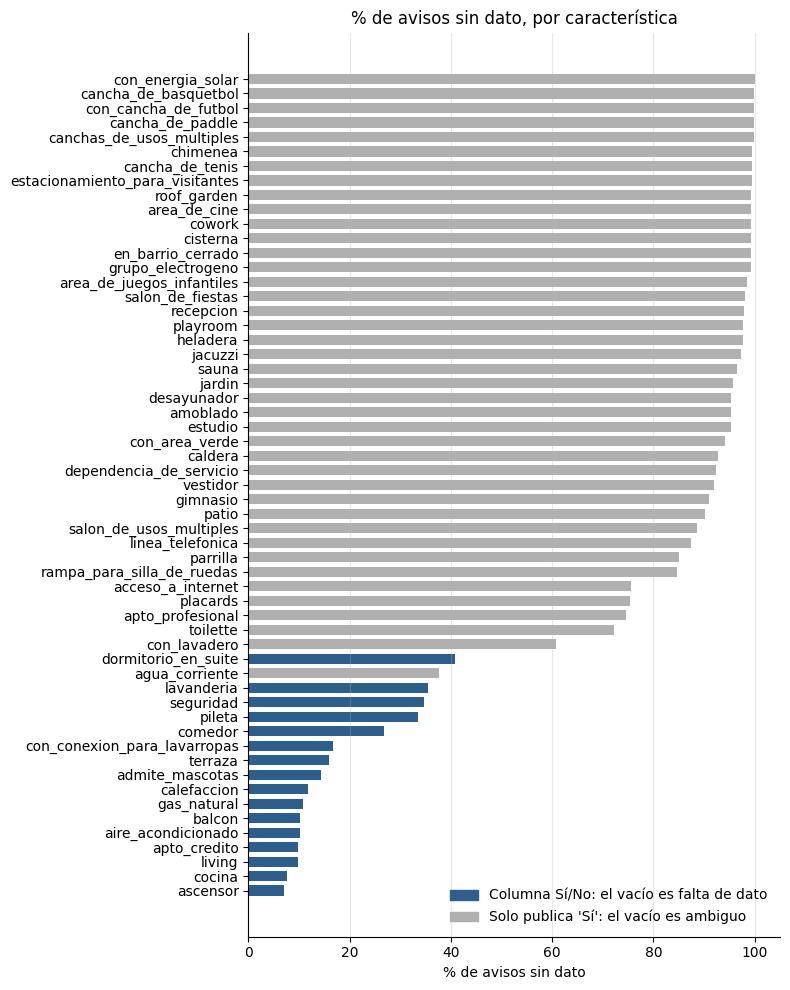

In [11]:
nulos = pd.DataFrame({
    "pct_nulos": (100 * df_crudo[amenities].isna().mean()).round(1),
    "tipo": mecanismo,
}).sort_values("pct_nulos")

fig, ax = plt.subplots(figsize=(8, 10))
colores = np.where(nulos["tipo"] == "solo_si", "#B0B0B0", "#2E5E8C")
ax.barh(nulos.index, nulos["pct_nulos"], color=colores, height=0.7)
ax.set_xlabel("% de avisos sin dato")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2E5E8C", label="Columna Sí/No: el vacío es falta de dato"),
                   Patch(color="#B0B0B0", label="Solo publica 'Sí': el vacío es ambiguo")],
          loc="lower right", frameon=False)
ax.set_title("% de avisos sin dato, por característica")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Resultado.** Hay dos mecanismos de ausencia distintos:

- **Columnas "Sí/No"** (gas, ascensor, pileta, balcón...): el vacío es falta de dato.
- **Columnas "solo Sí"** (gimnasio, SUM, parrilla, agua corriente...): la plataforma nunca publica "No".
  El vacío mezcla "no tiene" con "no lo cargó" y no hay forma de separarlos.

**Decisión:** los vacíos se dejan como están en el dataset limpio. En el modelo de precio esperado (notebook 03) las
características entran como "tiene / no lo declara"; un control por la completitud del aviso queda pendiente (README, sección 11).

> **Interpretación.** Imputar "No" en las columnas "solo Sí" sería asumir un dato que no tenemos: el vacío puede ser "no tiene" o "no lo cargó", y la plataforma no permite distinguirlos. En las columnas Sí/No, en cambio, el vacío está separado del "No", y eso permite usarlas como referencia para ver si los avisos sin dato se parecen más a los que tienen o a los que no tienen la característica.
>
> El sesgo no sería aleatorio. Los avisos cargados con menos detalle quedarían con menos amenities "en los papeles" que los que realmente tienen, y al comparar su precio contra sus características aparecerían como **caros para lo que ofrecen**. El error depende de quién cargó el aviso y con qué cuidado, no del inmueble, así que distorsionaría de forma sistemática el ranking de avisos que el analista del fondo después revisa.

### 2.4 Unidades, monedas y escalas

**Pregunta:** ¿los números están en la misma unidad y escala?

In [12]:
print("Moneda del precio:")
print(df_crudo["moneda"].value_counts(), "\n")
print("Moneda de las expensas:")
print(df_crudo["expensas"].str.extract(r"\s(ARS|USD)$")[0].value_counts(dropna=False))

Moneda del precio:
moneda
USD    27917
ARS        5
Name: count, dtype: int64 

Moneda de las expensas:
0
ARS    27048
NaN      833
USD       41
Name: count, dtype: int64


In [13]:
precios = limpieza.corregir_precio(df_crudo)
print("Avisos con precio concatenado ('BAJÓ DE PRECIO'):", precios["bajo_de_precio"].sum())
usd = df_crudo["moneda"] == "USD"
print(f"Media USD original:  {df_crudo.loc[usd, 'precio'].mean():>18,.0f}")
print(f"Media USD corregida: {precios.loc[usd, 'precio_actual'].mean():>18,.0f}")
print(f"Mediana USD original:  {df_crudo.loc[usd, 'precio'].median():,.0f}")
print(f"Mediana USD corregida: {precios.loc[usd, 'precio_actual'].median():,.0f}")
df_crudo.loc[precios["bajo_de_precio"], ["precio_texto", "precio"]].head(3)

Avisos con precio concatenado ('BAJÓ DE PRECIO'): 627
Media USD original:       5,215,103,339
Media USD corregida:            209,160
Mediana USD original:  135,000
Mediana USD corregida: 130,000


,precio_texto,precio
87,US$198.000US$185.000 BAJÓ DE PRECIO,198000185000
92,US$195.000US$185.000 BAJÓ DE PRECIO,195000185000
99,US$148.000US$138.000 BAJÓ DE PRECIO,148000138000


**Resultado.** En los avisos con la etiqueta "BAJÓ DE PRECIO" el scraper pegó el precio anterior y el
vigente en un solo número. Eso lleva la media en USD a miles de millones y corre la mediana de 130.000
a 135.000 (la cifra que quedó en el README de la PreEntrega 1).

In [14]:
print("Superficie cubierta con punto de miles (ambigua):",
      df_crudo["superficie_cubierta"].str.fullmatch(r"\d{1,3}\.\d{3} m²", na=False).sum())
print("Superficie en otra unidad (no m²):",
      (df_crudo["superficie_total"].notna() & ~df_crudo["superficie_total"].str.endswith(" m²", na=False)).sum())
print("Superficie del listado < 15 m²:", (df_crudo["m2"] < PARAMS["m2_minimo"]).sum())

antig_texto = df_crudo["antig_edad"].dropna()
print("Antigüedad negativa ('-2 años'):", antig_texto.str.startswith("-").sum())
print("Antigüedad cargada como año ('1.976 años'):", antig_texto.str.match(r"^\d\.\d{3}").sum())

Superficie cubierta con punto de miles (ambigua): 9
Superficie en otra unidad (no m²): 73
Superficie del listado < 15 m²: 36
Antigüedad negativa ('-2 años'): 235
Antigüedad cargada como año ('1.976 años'): 66


**Resultado.** La superficie tiene tres problemas de carga: valores menores a 15 m² en el listado, números con punto de miles que no se pueden interpretar ("45.000 m²" en un 2 ambientes) y algunos avisos con la superficie en hectáreas. Se tratan en la sección 3.3. La antigüedad tiene dos formatos raros: valores negativos y años de construcción cargados como edad ("1.976 años").

**¿Una antigüedad negativa es un error?** Se miran los títulos de esos avisos:

In [15]:
negativos = df_crudo[df_crudo["antig_edad"].str.startswith("-", na=False)]
negativos[["antig_edad", "titulo", "precio"]].head(10)

,antig_edad,titulo,precio
466,-2 años,Venta Monoambiente Balcon Palermo Hollywood Pozo,123200
522,-2 años,Venta Monoambiente Palermo Ideal Inversion,133000
532,-1 años,Venta Departamento Monoambiente Pozo Palermo A...,140600
564,-1 años,Venta Departamento 3 Ambientes Con Balcon Y Am...,291200
635,-1 años,Venta 2amb C/ Balcon Terraza-pozo- Palermo,222063
770,-2 años,Venta Departamento 2 Ambientes Palermo Air Bnb,254000
772,-2 años,Venta Duplex 2 Ambientes Palermo Holywood Balcon,364000
773,-2 años,Vta Depto 1 Amb C/balcon Exc Ubi Palermo,130000
779,-1 años,Venta Palermo Depto 3 Amb Al Frente Balcon Ame...,399500
780,-1 años,Venta Palermo Depto 2 Amb 68 M T Balcon Amenities,255000


> **Interpretación.** No es un error: los títulos muestran que son departamentos **en pozo**, y el valor negativo indica en cuántos años se estima la entrega. Se colaron a pesar del filtro de usados del scraping. Se suman 2 avisos con "40.000 años", que el parser lee como año de construcción y quedan negativos: son un error de carga, y también quedan fuera.
>
> Como el alcance del proyecto son departamentos **usados**, quedan fuera (sección 3.5). Además su precio responde a otra lógica, porque se paga antes de que exista el inmueble y con riesgo de obra, y en el modelo de precio esperado podrían aparecer como "baratos para lo que tienen" por ser pozo y no por estar mal valuados.

### 2.5 Coherencia entre variables relacionadas

**Pregunta:** ¿las variables que deberían ser consistentes entre sí lo son?

In [16]:
sup_cub = limpieza.parsear_superficie(df_crudo["superficie_cubierta"])
sup_tot = limpieza.parsear_superficie(df_crudo["superficie_total"])

coherencia = pd.Series({
    "dormitorios >= ambientes": (df_crudo["dormitorios"] >= df_crudo["ambientes"]).sum(),
    "piso de la unidad > pisos del edificio": (df_crudo["numero_de_piso_de_la_unidad"] > df_crudo["cantidad_de_pisos"]).sum(),
    "superficie cubierta > total": (sup_cub > sup_tot + 1).sum(),
    "departamentos_por_piso == 99": (df_crudo["departamentos_por_piso"] == 99).sum(),
    "ambientes == 0": (df_crudo["ambientes"] == 0).sum(),
}, name="avisos")
coherencia.to_frame()

,avisos
dormitorios >= ambientes,2030
piso de la unidad > pisos del edificio,2307
superficie cubierta > total,30
departamentos_por_piso == 99,6970
ambientes == 0,312


**Resultado.** `departamentos_por_piso = 99` (casi 7.000 avisos) y `ambientes = 0` (312) son faltantes disfrazados: no son valores posibles y se tratan como dato faltante en la sección 3.4. Las demás inconsistencias se **marcan** pero no se corrigen, porque no hay forma de saber cuál de las dos variables está mal.

**¿Es siempre un error que un aviso tenga tantos dormitorios como ambientes, o más?** Se cruzan las dos variables para los 2.030 avisos en esa situación:

In [17]:
raros = df_crudo[df_crudo["dormitorios"] >= df_crudo["ambientes"]]
pd.crosstab(raros["ambientes"], raros["dormitorios"])

dormitorios,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,11.0,13.0,38.0
ambientes,,,,,,,,,,,,,
-1,0,0,0,1,0,0,0,0,0,0,0,0,0
0,243,20,17,18,9,0,0,5,0,0,0,0,0
1,0,1331,4,0,0,1,0,0,0,0,0,0,0
2,0,0,67,0,0,0,0,0,0,0,1,0,1
3,0,0,0,157,1,0,0,0,0,0,0,0,0
4,0,0,0,0,124,5,1,0,1,0,0,0,0
5,0,0,0,0,0,8,2,0,0,1,0,0,0
6,0,0,0,0,0,0,5,1,0,0,0,0,0
7,0,0,0,0,0,0,0,1,0,0,0,0,0


> **Interpretación.** No siempre es un error. El caso más frecuente, 1 ambiente con 1 dormitorio (1.331 avisos), es la forma en que la plataforma registra un monoambiente: es una convención, no una inconsistencia.
>
> Para 2 o más ambientes la diagonal no cierra: según la convención argentina, ambientes = dormitorios + living, así que un 3 ambientes tiene 2 dormitorios. Los cerca de 350 avisos con 2/2, 3/3 o 4/4 probablemente tienen uno de los dos campos mal cargado, y los que tienen más dormitorios que ambientes (2 ambientes con 38 dormitorios) son errores directos. La fila de `ambientes = 0` (312 avisos en total) es otro faltante disfrazado.
>
> Como no hay forma de saber cuál de los dos campos está mal, estos avisos se marcan con `incoherencia_dormitorios` en lugar de corregirse, y para medir el tamaño el análisis se apoya en la superficie (m²), que es más confiable.

### 2.6 Valores atípicos

**Pregunta:** ¿los precios extremos son errores o segmentos reales?

In [18]:
precio_corr = precios["precio_actual"]
df_tmp = df_crudo.assign(precio_usd=precio_corr)
df_tmp = df_tmp[df_tmp["moneda"] == "USD"]
print("Avisos > USD 3 millones:", (df_tmp["precio_usd"] > 3_000_000).sum())
print("Avisos < USD 20.000:    ", (df_tmp["precio_usd"] < PARAMS["precio_minimo_usd"]).sum())
df_tmp.nlargest(6, "precio_usd")[["precio_usd", "m2", "barrio", "titulo"]]

Avisos > USD 3 millones: 39
Avisos < USD 20.000:     4


,precio_usd,m2,barrio,titulo
6173,111111111.0,163.0,recoleta,Impresionante Penthouse En Torre De Categoria ...
2354,12000000.0,367.0,belgrano,Belgrano R-venta- Excepcional Edificio De Cate...
2355,12000000.0,367.0,belgrano,Belgrano R-venta- Excepcional Edificio De Cate...
2975,12000000.0,367.0,belgrano,Departamento Piso En Venta Ubicado En Belgrano...
15499,9500000.0,485.0,puerto-madero,Departamento En Venta Alvear Tower Puerto Made...
2161,7900000.0,650.0,belgrano,Casa En Venta - 6 Ambientes - Terraza Propia -...


In [19]:
df_tmp.nsmallest(5, "precio_usd")[["precio_usd", "m2", "barrio", "titulo"]]

,precio_usd,m2,barrio,titulo
24480,1100.0,920.0,villa-luro,Departamento En Venta En Av. Emilio Castro 490...
15490,3000.0,54.0,puerto-madero,Departamento En Alquiler Alvear Icon Puerto Ma...
24918,3800.0,1.0,liniers,Villa Luro. Larrazabal 700. Departamentos 3 Y ...
24919,3800.0,1.0,liniers,Liniers. Larrazabal 700. Departamentos 3 Y 4 A...
21315,23000.0,34.0,constitucion,Venta Departamento Monoambiente Constitución A...


**Resultado.** Entre los más caros hay un error de carga (USD 111 millones por 163 m², que se excluye como precio
imposible), tres avisos de un edificio entero en Belgrano (USD 12 millones), una unidad de lujo real (Alvear Tower) y
una casa publicada como departamento (USD 7,9 millones), fuera de la tipología. Se conservan, pero los edificios y la
casa quedan marcados como atípicos de precio por m² (sección 3.6), así que no se usan para ajustar el modelo. Los de menos de USD 20.000 son alquileres publicados en la categoría equivocada o
errores de carga (USD 1.100 por 920 m²): quedan fuera del alcance.

Para los atípicos de precio por m² se usa IQR **dentro de cada sub-zona** (sección 3.6): un precio
puede ser normal en Puerto Madero y atípico en Lugano.

### 2.7 Cobertura temporal, geográfica y sesgos de captura

**Pregunta:** ¿qué parte del mercado representa el dataset y qué queda afuera?

In [20]:
por_barrio = df_crudo.groupby("barrio").agg(
    avisos=("link", "size"),
    geocodificados=("geo_status", lambda s: (s == "OK").mean()),
).sort_values("avisos", ascending=False)
por_barrio["geocodificados"] = (100 * por_barrio["geocodificados"]).round(1)
print("Barrios:", len(por_barrio))
print("Barrios en el tope de paginación (2.016 avisos):", (por_barrio["avisos"] == 2016).sum())
por_barrio.head(6)

Barrios: 47
Barrios en el tope de paginación (2.016 avisos): 4


,avisos,geocodificados
barrio,,
belgrano,2016,81.2
caballito,2016,80.0
palermo,2016,84.5
recoleta,2016,82.8
balvanera,1625,87.7
almagro,1606,85.5


In [21]:
por_barrio.sort_values("geocodificados").head(6)

,avisos,geocodificados
barrio,,
puerto-madero,756,59.5
villa-real,19,63.2
villa-lugano,428,63.8
nueva-pompeya,49,69.4
villa-general-mitre,122,69.7
la-boca,237,72.6


**Resultado.**

- **Temporal:** una sola foto, 14/08/2026. No hay fecha de publicación de cada aviso.
- **Geográfica:** 47 barrios. Cuatro barrios (Palermo, Belgrano, Caballito, Recoleta) quedaron cortados
  en 2.016 avisos por el tope de la plataforma: su oferta real es mayor.
- **Geocodificación:** 82% del total, pero desigual entre barrios (Puerto Madero 60%, Boedo 92%).
- **Fuente:** solo MercadoLibre. Los avisos de otras plataformas (Zonaprop, Argenprop) no están.

> **Interpretación.** El scraper no pidió un orden específico, así que MercadoLibre devolvió los resultados en su orden por defecto ("Más relevantes"), que prioriza avisos destacados (pagos), vendedores con mayor reputación y volumen, y publicaciones más completas. En Palermo, Belgrano, Caballito y Recoleta, el tope de 2.016 avisos hizo que se capturara solo esa parte alta del ranking.
>
> El sesgo favorece a avisos de inmobiliarias grandes y bien cargados, no necesariamente a los más caros: con estos datos no se puede medir hacia qué lado mueve los precios. Pero tiene una consecuencia directa para el proyecto: los avisos de particulares o inmobiliarias chicas, que son los más propensos a tener precios atípicos para su zona, tienen menos chances de aparecer. En esos cuatro barrios el dataset podría subrepresentar justamente los casos que el fondo busca. Una corrección posible para futuras extracciones es dividir la búsqueda en rangos de precio, para que ninguna consulta supere el tope.

## 3. Limpieza y preprocesamiento

Cada paso agrega columnas nuevas y no pisa las originales.

### 3.1 Duplicados por ID de aviso

In [22]:
n_antes = len(df)
duplicados_id = df[df["id_aviso"].duplicated(keep="first")].copy()
duplicados_id["motivo"] = "duplicado_mismo_id"
df = df.drop_duplicates("id_aviso", keep="first").copy()
print(f"Eliminados: {n_antes - len(df)} | Quedan: {len(df):,}")

Eliminados: 68 | Quedan: 27,854


Se conserva la primera aparición. El barrio asignado es el de la primera búsqueda que lo devolvió.

### 3.2 Precio corregido

In [23]:
precios = limpieza.corregir_precio(df)
df["precio_usd"] = precios["precio_actual"]
df["precio_anterior_usd"] = precios["precio_anterior"]
df["bajo_de_precio"] = precios["bajo_de_precio"]
df["baja_pct"] = precios["baja_pct"].round(1)

# Control: en los avisos sin baja el precio corregido es idéntico al original
sin_baja = ~df["bajo_de_precio"]
print("Coinciden con el original (sin baja):", (df.loc[sin_baja, "precio_usd"] == df.loc[sin_baja, "precio"]).all())
print("Avisos que bajaron de precio:", df["bajo_de_precio"].sum())
print(df["baja_pct"].describe().round(1))

Coinciden con el original (sin baja): True
Avisos que bajaron de precio: 626
count    626.0
mean       7.8
std        3.0
min        5.0
25%        5.8
50%        6.8
75%        8.7
max       30.8
Name: baja_pct, dtype: float64


`bajo_de_precio` es una variable nueva. La baja mínima es 5%, lo que sugiere que la plataforma solo
muestra la etiqueta a partir de ese umbral.

### 3.3 Superficie y precio por m²

In [24]:
df["m2_final"], df["m2_origen"] = limpieza.superficie_final(df, PARAMS["m2_minimo"], PARAMS["m2_maximo"])
df["m2_origen"].value_counts()

m2_origen
listado                27792
recuperada_de_total       32
invalida                  30
Name: count, dtype: int64

In [25]:
df["precio_m2_usd"] = df["precio_usd"] / df["m2_final"]
df.loc[df["m2_origen"] == "recuperada_de_total", ["m2", "superficie_total", "m2_final", "ambientes"]].head()

,m2,superficie_total,m2_final,ambientes
2709,1.0,26 m²,26.0,1
2735,NaN,97 m²,97.0,4
3914,8.0,92 m²,92.0,4
8407,3.0,31 m²,31.0,1
8491,NaN,53 m²,53.0,2


### 3.4 Antigüedad, expensas, tipo de cambio y faltantes disfrazados

In [26]:
df["antiguedad"], df["en_construccion"] = limpieza.parsear_antiguedad(
    df["antig_edad"], PARAMS["anio_referencia"], PARAMS["antiguedad_maxima"]
)
print("En pozo (se excluyen en 3.5):", df["en_construccion"].sum())
print(df["antiguedad"].describe().round(1))

En pozo (se excluyen en 3.5): 237
count    27071.0
mean        35.2
std         23.3
min          0.0
25%         12.0
50%         40.0
75%         50.0
max        146.0
Name: antiguedad, dtype: float64


In [27]:
df["expensas_monto"], df["expensas_moneda"] = limpieza.parsear_expensas(
    df["expensas"], PARAMS["expensas_maximo_ars"]
)
print("Expensas en 0 o absurdas, pasadas a NaN:",
      (df["expensas"].notna() & df["expensas_monto"].isna()).sum())
print("Expensas en USD:", (df["expensas_moneda"] == "USD").sum())

Expensas en 0 o absurdas, pasadas a NaN: 3855
Expensas en USD: 32


**Normalización monetaria de las expensas.** El precio está en dólares y las expensas, casi todas en pesos. De los 41 avisos que las marcan en dólares, 9 tienen montos típicos de pesos ("222.000 USD"): se leen como pesos con la moneda mal cargada. Los de 0 o 1 dólar quedan como sin dato. Para compararlas se unifican a pesos y se convierten a dólares con un único tipo de cambio:

| | Valor |
|---|---|
| Tipo de cambio | Dólar MEP, 1.518,05 ARS por USD (cierre) |
| Fecha de referencia | 14/08/2026, fecha del scraping |
| Fuente | Ámbito, cotización de cierre del 14/08/2026 |
| Alternativa considerada | Oficial mayorista Com. "A" 3500 del BCRA: 1.488,70 |

**Criterio:** el comprador paga el departamento con dólares propios y las expensas en pesos, así que lo relevante es cuántos de sus dólares se le van por mes. El MEP es el tipo de cambio al que una persona convierte legalmente dólares a pesos; el A 3500 es mayorista y un comprador no accede a él. La diferencia entre ambos era de 2%, así que la elección pesa poco. Detalle y fuentes en `docs/entregas_grupo/contexto_argentino.md`.

In [28]:
tc = PARAMS["tipo_cambio_ars_usd"]
df["expensas_ars"] = limpieza.expensas_en_ars(df["expensas_monto"], df["expensas_moneda"], tc)
df["expensas_usd"] = df["expensas_ars"] / tc
print(f"Tipo de cambio: {tc:,.2f} ARS por USD")
print(f"Mediana de expensas: ARS {df['expensas_ars'].median():,.0f} = USD {df['expensas_usd'].median():,.1f}")

Tipo de cambio: 1,518.05 ARS por USD
Mediana de expensas: ARS 200,000 = USD 131.7


In [29]:
# Faltantes disfrazados: valores imposibles que en realidad significan "sin dato"
df["departamentos_por_piso"] = df["departamentos_por_piso"].replace(99, np.nan)
df["ambientes"] = df["ambientes"].replace(0, np.nan)
print("departamentos_por_piso == 99 restantes:", (df["departamentos_por_piso"] == 99).sum())
print("ambientes == 0 restantes:", (df["ambientes"] == 0).sum())

departamentos_por_piso == 99 restantes: 0
ambientes == 0 restantes: 0


### 3.5 Registros fuera del alcance

Alcance: departamento usado en venta, con precio en USD y una superficie interpretable.

In [30]:
df["motivo_exclusion"] = limpieza.motivo_fuera_de_alcance(
    df, PARAMS["precio_minimo_usd"], PARAMS["precio_m2_maximo_usd"]
)
df["motivo_exclusion"].value_counts()

motivo_exclusion
en_pozo                  237
superficie_invalida       28
precio_en_pesos            5
precio_menor_a_minimo      4
precio_imposible           1
Name: count, dtype: int64

In [31]:
excluidos = df[df["motivo_exclusion"].notna()].copy()
excluidos[["id_aviso", "motivo_exclusion", "moneda", "precio_usd", "m2", "superficie_total", "titulo"]].head(10)

,id_aviso,motivo_exclusion,moneda,precio_usd,m2,superficie_total,titulo
466,MLA1982315645,en_pozo,USD,123200.0,35.0,39 m²,Venta Monoambiente Balcon Palermo Hollywood Pozo
522,MLA1961480147,en_pozo,USD,133000.0,35.0,39 m²,Venta Monoambiente Palermo Ideal Inversion
532,MLA3745642248,en_pozo,USD,140600.0,35.0,39 m²,Venta Departamento Monoambiente Pozo Palermo A...
564,MLA1948885929,en_pozo,USD,291200.0,74.0,"84,24 m²",Venta Departamento 3 Ambientes Con Balcon Y Am...
635,MLA1945613169,en_pozo,USD,222063.0,52.0,67 m²,Venta 2amb C/ Balcon Terraza-pozo- Palermo
770,MLA3720476470,en_pozo,USD,254000.0,49.0,61 m²,Venta Departamento 2 Ambientes Palermo Air Bnb
772,MLA3720476460,en_pozo,USD,364000.0,76.0,88 m²,Venta Duplex 2 Ambientes Palermo Holywood Balcon
773,MLA3720476544,en_pozo,USD,130000.0,35.0,39 m²,Vta Depto 1 Amb C/balcon Exc Ubi Palermo
779,MLA3720475928,en_pozo,USD,399500.0,85.0,107 m²,Venta Palermo Depto 3 Amb Al Frente Balcon Ame...
780,MLA3720475930,en_pozo,USD,255000.0,57.0,68 m²,Venta Palermo Depto 2 Amb 68 M T Balcon Amenities


In [32]:
df_limpio = df[df["motivo_exclusion"].isna()].drop(columns="motivo_exclusion").copy()
print(f"Quedan {len(df_limpio):,} avisos dentro del alcance")

Quedan 27,579 avisos dentro del alcance


### 3.6 Marcas (no se elimina nada)

Columnas booleanas para que el EDA pueda comparar con y sin cada grupo.

In [33]:
df_limpio["posible_duplicado"] = limpieza.marcar_posible_duplicado(df_limpio)
df_limpio["menciona_alquiler"] = limpieza.menciona_alquiler(df_limpio["titulo"])
print("Posibles duplicados (mismo precio, m², dirección y ambientes):", df_limpio["posible_duplicado"].sum())
print("Título menciona alquiler:", df_limpio["menciona_alquiler"].sum())

Posibles duplicados (mismo precio, m², dirección y ambientes): 3059
Título menciona alquiler: 162


In [34]:
df_limpio.loc[df_limpio["menciona_alquiler"], ["precio_usd", "m2_final", "precio_m2_usd", "titulo"]].head(5)

,precio_usd,m2_final,precio_m2_usd,titulo
183,139000.0,52.0,2673.076923,Departamento - Venta Y Alquiler - Palermo Soho
367,175000.0,75.0,2333.333333,Venta Alquiler Departamento Tres Ambientes Con...
881,138000.0,35.0,3942.857143,"Venta Monoambiente Para Alquiler Temporario, R..."
1140,69000.0,26.0,2653.846154,Departamento En Alquiler Ambiente Super Luminoso
1171,295000.0,46.0,6413.043478,Alquiler Departamento 2 Ambientes Piso Alto - ...


Los avisos que mencionan alquiler tienen precios de **venta** (por ejemplo, USD 69.000 por 26 m²) y
están en la categoría venta de la plataforma: el título está mal puesto. Por eso se marcan y no se
excluyen.

In [35]:
# Outliers de precio por m²: IQR dentro de la sub-zona; si no hay sub-zona (no geocodificado), dentro del barrio
grupo = df_limpio["subzona"].fillna(df_limpio["barrio"])
df_limpio["outlier_precio_m2"] = limpieza.outliers_iqr_por_grupo(
    df_limpio["precio_m2_usd"], grupo, k=PARAMS["iqr_k"]
)
print(f"Outliers de precio/m² (IQR k={PARAMS['iqr_k']} por sub-zona):",
      df_limpio["outlier_precio_m2"].sum(),
      f"({100 * df_limpio['outlier_precio_m2'].mean():.1f}%)")

Outliers de precio/m² (IQR k=1.5 por sub-zona): 928 (3.4%)


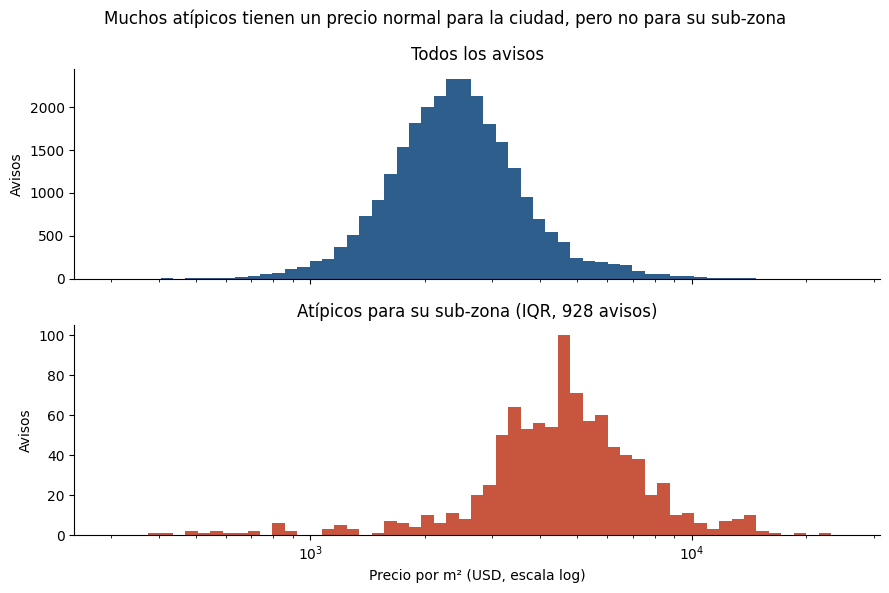

In [36]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
bins = np.logspace(np.log10(300), np.log10(25000), 60)
atipicos = df_limpio.loc[df_limpio["outlier_precio_m2"], "precio_m2_usd"]
ax1.hist(df_limpio["precio_m2_usd"], bins=bins, color="#2E5E8C")
ax1.set_title("Todos los avisos")
ax2.hist(atipicos, bins=bins, color="#C8553D")
ax2.set_title(f"Atípicos para su sub-zona (IQR, {len(atipicos)} avisos)")
ax2.set_xscale("log")
ax2.set_xlabel("Precio por m² (USD, escala log)")
for ax in (ax1, ax2):
    ax.set_ylabel("Avisos")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Muchos atípicos tienen un precio normal para la ciudad, pero no para su sub-zona")
plt.tight_layout()
plt.show()

> **Interpretación.** Un mismo precio por m² puede ser normal en un barrio y atípico en otro: la mediana va de unos USD 1.000/m² en Villa Lugano a más de USD 6.000/m² en Puerto Madero. Por eso hay atípicos en el medio de la distribución general: un departamento de Villa Lugano a USD 1.800/m² está por debajo de la mediana de la ciudad, pero casi duplica la de su barrio.
>
> Un único corte para toda CABA fallaría en los dos sentidos: no detectaría casos como ese y marcaría como atípicos a departamentos comunes de las zonas caras. Por eso el criterio IQR se aplica dentro de cada sub-zona, que es además la unidad de comparación del proyecto. Casi todos los atípicos detectados (96%) están por encima del precio típico de su sub-zona. Los que están por debajo son muy pocos, y son justamente los que más le interesan al fondo, como señal para investigar.

In [37]:
# 1 ambiente con 1 dormitorio es la convención de la plataforma para un monoambiente (sección 2.5): no se marca
es_monoambiente = (df_limpio["ambientes"] == 1) & (df_limpio["dormitorios"] == 1)
df_limpio["incoherencia_dormitorios"] = (df_limpio["dormitorios"] >= df_limpio["ambientes"]) & ~es_monoambiente
df_limpio["incoherencia_piso"] = df_limpio["numero_de_piso_de_la_unidad"] > df_limpio["cantidad_de_pisos"]
df_limpio[["incoherencia_dormitorios", "incoherencia_piso"]].sum()

incoherencia_dormitorios     376
incoherencia_piso           2299
dtype: int64

### 3.7 Registro de lo eliminado y comparación crudo vs. procesado

In [38]:
registro = pd.concat([
    duplicados_id[["id_aviso", "link", "barrio", "precio", "m2", "motivo"]],
    excluidos[["id_aviso", "link", "barrio", "precio", "m2", "motivo_exclusion"]].rename(
        columns={"motivo_exclusion": "motivo"}),
], ignore_index=True)
registro["motivo"].value_counts()

motivo
en_pozo                  237
duplicado_mismo_id        68
superficie_invalida       28
precio_en_pesos            5
precio_menor_a_minimo      4
precio_imposible           1
Name: count, dtype: int64

In [39]:
def resumen_dataset(d, col_precio):
    usd = d[d["moneda"] == "USD"]
    return pd.Series({
        "filas": len(d),
        "columnas": d.shape[1],
        "mediana precio USD": usd[col_precio].median(),
        "media precio USD": usd[col_precio].mean(),
        "IDs duplicados": limpieza.extraer_id_aviso(d["link"]).duplicated().sum(),
        "geocodificados (%)": 100 * (d["geo_status"] == "OK").mean(),
    })


comparacion = pd.DataFrame({
    "crudo": resumen_dataset(df_crudo, "precio"),
    "procesado": resumen_dataset(df_limpio, "precio_usd"),
})
def formato(v, fila):
    texto = f"{v:,.1f}" if fila == "geocodificados (%)" else f"{v:,.0f}"
    return texto.replace(",", "X").replace(".", ",").replace("X", ".")


comparacion.apply(lambda col: [formato(v, fila) for fila, v in col.items()])

,crudo,procesado
filas,27.922,27.579
columnas,93,112
mediana precio USD,135.000,130.000
media precio USD,5.215.103.339,205.283
IDs duplicados,68,0
geocodificados (%),"82,1","82,1"


### 3.8 Guardar

In [40]:
df_limpio.to_csv(PARAMS["salida"], sep="\t", index=False)
registro.to_csv(PARAMS["salida_registro"], index=False)
print("Guardado:", PARAMS["salida"].relative_to(RAIZ), df_limpio.shape)
print("Guardado:", PARAMS["salida_registro"].relative_to(RAIZ), registro.shape)

Guardado: data/processed/propiedades_limpias.tsv (27579, 112)
Guardado: data/processed/registro_limpieza.csv (343, 6)


## 4. Conclusiones de la limpieza

**Problemas de calidad detectados.** Dataset final: 27.579 avisos (se excluyeron 343, detalle en `data/processed/registro_limpieza.csv`).

| Problema | Avisos | Tratamiento |
|---|---|---|
| Mismo aviso dos veces (ID repetido, link distinto; 27 en dos barrios) | 68 | Eliminado, se conserva la primera aparición |
| Precio concatenado por "BAJÓ DE PRECIO" | 627 | Corregido; nace `bajo_de_precio` |
| Precio en pesos (compradores, alquileres) | 5 | Fuera de alcance |
| Precio < USD 20.000 | 4 | Fuera de alcance |
| Precio > USD 50.000/m² (error de carga) | 1 | Fuera de alcance |
| Superficie < 15 m² o ambigua | 32 recuperadas, 28 excluidas | Recuperada de la superficie total cuando es posible; si no, fuera de alcance |
| Departamentos en pozo (235 con antigüedad negativa, más 2 "40.000 años" que el parser deja negativos) | 237 | Fuera de alcance (no son usados) |
| Antigüedad cargada como año de construcción | 66 | Convertida a edad |
| Expensas en 0 o absurdas | 3.855 | NaN (0 se lee como "no informado") |
| Expensas marcadas en USD | 41 (25 en 0 o 1 USD, 9 montos en pesos con la moneda mal cargada, 7 en dólares reales) | Las de 10.000 o más se leen como pesos; las menores a 10, sin dato; todas se unifican y convierten al dólar MEP del 14/08/2026 |
| `departamentos_por_piso = 99` | 6.970 | NaN (faltante disfrazado) |
| `ambientes = 0` | 312 | NaN (faltante disfrazado) |
| Mismo precio, m², dirección y ambientes con otro ID | 3.059 | Marcado (`posible_duplicado`) |
| Dormitorios mayor o igual que ambientes (sin contar el monoambiente 1/1) | 376 | Marcado (`incoherencia_dormitorios`) |
| Piso de la unidad mayor que la cantidad de pisos | 2.299 | Marcado (`incoherencia_piso`) |
| Título menciona alquiler con precio de venta | 162 | Marcado (`menciona_alquiler`) |
| Precio por m² atípico para su sub-zona | 928 (3,4%) | Marcado (`outlier_precio_m2`) |
| Columnas "solo Sí" de amenities | 41 columnas | Sin imputar; en el modelo entran como "lo declara / no lo declara" |

Las expensas quedan unificadas en `expensas_ars` y `expensas_usd`, convertidas al dólar MEP del 14/08/2026 (sección 3.4).

> **Interpretación.** El dataset limpio es confiable para comparar precios dentro de una zona: el precio quedó corregido, no hay avisos repetidos, los casos fuera de alcance están excluidos y documentados, y lo dudoso quedó marcado en lugar de borrado.
>
> La limitación que más preocupa son los vacíos en las columnas de amenities. Muchos anunciantes no cargan todas las características, y eso puede hacer que un aviso parezca caro para lo que ofrece cuando en realidad está incompleto. No se puede corregir el dato; en el modelo de precio esperado las características entran como "lo declara / no lo declara", y un control por la completitud del aviso queda pendiente (README, sección 11). Una segunda limitación de fondo es que se trabaja con precio de publicación y no de cierre.